In [72]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

Baris kode ini merupakan bagian untuk mengimpor library yang dibutuhkan. Library numpy diimpor dengan alias np dan digunakan untuk melakukan operasi matematis pada array multidimensi yang merepresentasikan piksel gambar. Library matplotlib.pyplot diimpor dengan alias plt dan digunakan untuk menampilkan gambar maupun grafik histogram secara visual. Library cv2 diimpor dan digunakan khusus untuk membaca file gambar dari disk serta mengubahnya ke format grayscale.

Selanjutnya, dilakukan pembacaan empat file gambar menggunakan dua library berbeda, yaitu Matplotlib (plt.imread) dan OpenCV (cv2.imread). Perbedaannya adalah Matplotlib memuat gambar dalam format warna RGB, sedangkan OpenCV memuatnya dalam format BGR. Gambar meledak dibaca menggunakan plt sesuai dengan soal jurnal yang menampilkan warna citra aslinya.

(720, 720, 3)


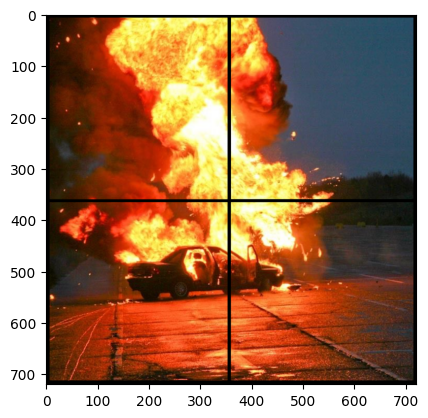

In [73]:
meledak_img = plt.imread("Assets/Meledak.png")
windut_img = cv2.imread("Assets/Windut.png")
bunga_img = cv2.imread("Assets/Bunga.png")
langit_img = cv2.imread("Assets/Langit.png")

plt.imshow(meledak_img)
print(meledak_img.shape)

In [74]:
def slice(image, a, b, mode='H'):
    return image[a:b, :] if mode == 'H' else image[:, a:b]

Fungsi slice tersebut digunakan untuk mengekstraksi atau memotong bagian tertentu dari sebuah citra berdasarkan rentang indeks a hingga b. Logika fungsinya bergantung pada parameter mode, jika bernilai 'H' (Horizontal), fungsi akan melakukan pemotongan pada baris (sumbu Y) untuk mengambil potongan gambar secara mendatar, sedangkan jika bernilai lain, fungsi akan memotong kolom (sumbu X) untuk mengambil potongan secara vertikal.

Kode di bawah bertujuan untuk membagi gambar meledak_img menjadi dua potongan horizontal yang berbeda dengan memanfaatkan fungsi slice yang telah didefinisikan sebelumnya. Variabel meledak_slice1 mengambil area gambar dari baris ke-20 hingga 360, sedangkan meledak_slice2 mengambil area dari baris ke-380 hingga 720. Dengan demikian, didapatkan dua gambar seperti di bawah ini.

(340, 720, 3)
(340, 720, 3)


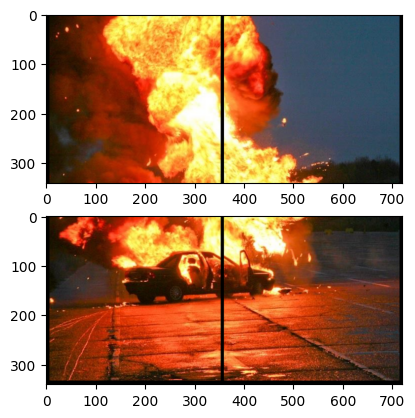

In [75]:
meledak_slice1 = slice(meledak_img, 20, 360, 'H')
meledak_slice2 = slice(meledak_img, 380, 720, 'H')

plt.subplot(2, 1, 1)
plt.imshow(meledak_slice1)
plt.subplot(2, 1, 2)
plt.imshow(meledak_slice2)

print(meledak_slice1.shape)
print(meledak_slice2.shape)

Kode di bawah ini melakukan pemotongan secara vertikal (berdasarkan kolom) terhadap dua gambar yang telah dibuat sebelumnya untuk membagi gambar menjadi empat bagian. Dengan menggunakan mode 'V', potongan meledak_slice1 (bagian atas) dibelah menjadi area kiri dan kanan (slice3 dan slice4), begitu pula dengan meledak_slice2 (bagian bawah) yang dibelah menjadi slice5 dan slice6. Dengan demikian, didapatkan empat potongan gambar seperti di bawah ini.

(340, 340, 3)
(340, 340, 3)
(340, 340, 3)
(340, 340, 3)


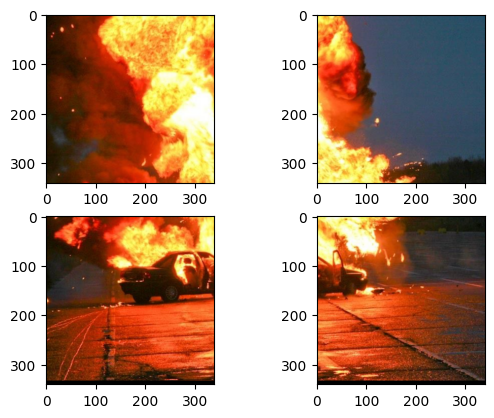

In [76]:
meledak_slice3 = slice(meledak_slice1, 10, 350, 'V')
meledak_slice4 = slice(meledak_slice1, 360, 700, 'V')
meledak_slice5 = slice(meledak_slice2, 10, 350, 'V')
meledak_slice6 = slice(meledak_slice2, 360, 700, 'V')

plt.subplot(2,2,1)
plt.imshow(meledak_slice3)
plt.subplot(2,2,2)
plt.imshow(meledak_slice4)
plt.subplot(2,2,3)
plt.imshow(meledak_slice5)
plt.subplot(2,2,4)
plt.imshow(meledak_slice6)

print(meledak_slice3.shape)
print(meledak_slice4.shape)
print(meledak_slice5.shape)
print(meledak_slice6.shape)


In [77]:
def merge_image(citra1, citra2, orientation): 
     
    if orientation == 'H':   
        tinggi = max(citra1.shape[0], citra2.shape[0]) 
        lebar_total = citra1.shape[1] + citra2.shape[1] 
         
        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi, lebar_total), dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi, lebar_total, citra1.shape[2]), dtype=citra1.dtype) 
         
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        gabungan[0:citra2.shape[0], citra1.shape[1]:citra1.shape[1]+citra2.shape[1]] = citra2 
         
    else:   
        tinggi_total = citra1.shape[0] + citra2.shape[0] 
        lebar = max(citra1.shape[1], citra2.shape[1]) 
         
        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi_total, lebar), dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi_total, lebar, citra1.shape[2]), dtype=citra1.dtype) 
         
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        gabungan[citra1.shape[0]:citra1.shape[0]+citra2.shape[0], 0:citra2.shape[1]] = citra2 
     
    return gabungan

Fungsi merge_image tersebut berfungsi untuk menggabungkan dua buah citra menjadi satu gambar utuh berdasarkan orientasi yang ditentukan, yaitu horizontal atau vertikal. Jika orientasi yang dipilih adalah 'H', kode akan menghitung lebar total kedua gambar dan menempatkannya berdampingan. Jika tidak, gambar akan disusun secara menumpuk dari atas ke bawah.

Kode di bawah melakukan penggabungan kembali potongan-potongan gambar secara vertikal untuk membentuk dua kolom utama menggunakan fungsi merge_image dengan parameter 'V'. Variabel merge35 menyatukan potongan kiri atas dengan kiri bawah menjadi satu bagian vertikal utuh di sisi kiri, sementara merge46 menyatukan potongan kanan atas dengan kanan bawah menjadi bagian vertikal di sisi kanan. Dengan demikian, didapatkan dua gambar seperti di bawah ini.

(680, 340, 3)
(680, 340, 3)


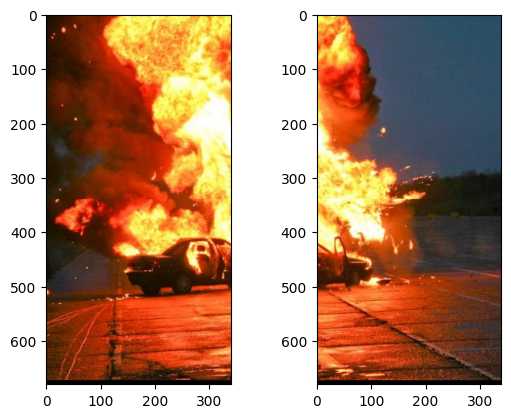

In [78]:
merge35 = merge_image(meledak_slice3, meledak_slice5, 'V')
merge46 = merge_image(meledak_slice4, meledak_slice6, 'V')

plt.subplot(1, 2, 1)
plt.imshow(merge35)
plt.subplot(1, 2, 2)
plt.imshow(merge46)

print(merge35.shape)
print(merge46.shape)

Kode di bawah ini merupakan langkah akhir untuk menyatukan kembali seluruh potongan gambar dengan menggabungkan kolom kiri (merge35) dan kolom kanan (merge46) secara horizontal menggunakan fungsi merge_image. Dengan parameter 'H', kedua bagian tersebut diletakkan berdampingan sehingga menghasilkan variabel merge3546 yang merekonstruksi tampilan utuh dari potongan-potongan sebelumnya. Dengan demikian, didapatkan satu gambar utuh seperti di bawah ini.

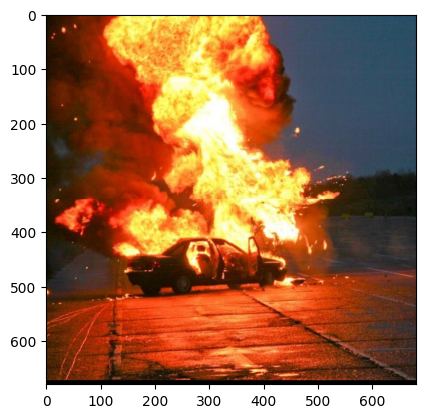

In [79]:
merge3546 = merge_image(merge35, merge46, 'H')
plt.imshow(merge3546)

Kode di bawah ini berfungsi untuk mengonversi empat citra RGB menjadi format grayscale menggunakan fungsi cv2.cvtColor. Dengan menerapkan parameter cv2.COLOR_BGR2GRAY, setiap gambar yang awalnya memiliki tiga saluran warna (Merah, Hijau, Biru) disederhanakan menjadi satu saluran intensitas cahaya saja. Ditampilkan juga grayscale dari citra meledak untuk proses selanjutnya.

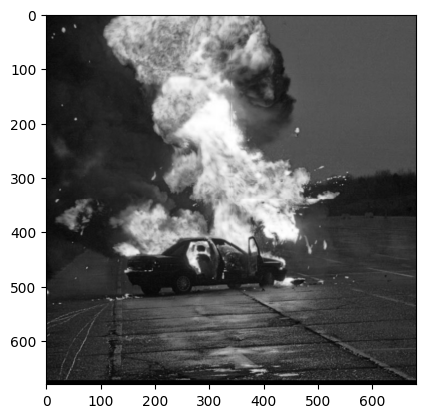

In [80]:
meledak_gray = cv2.cvtColor(merge3546, cv2.COLOR_BGR2GRAY)
windut_gray = cv2.cvtColor(windut_img, cv2.COLOR_BGR2GRAY)
bunga_gray = cv2.cvtColor(bunga_img, cv2.COLOR_BGR2GRAY)
langit_gray = cv2.cvtColor(langit_img, cv2.COLOR_BGR2GRAY)

plt.imshow(meledak_gray, cmap='gray')

In [81]:
def normalize_min_max(image):
    min_val = np.min(image)
    max_val = np.max(image)
    if max_val == min_val:
        return np.zeros_like(image, dtype=np.uint8) 
    norm = (image - min_val) / (max_val - min_val)
    return (norm * 255).astype(np.uint8)

Fungsi normalize_min_max bertujuan untuk mengatur ulang rentang intensitas piksel citra agar tersebar secara optimal dalam skala standar 0 hingga 255. Kode ini bekerja dengan mencari nilai terendah dan tertinggi pada gambar, lalu menerapkan rumus normalisasi untuk memetakan nilai piksel ke rentang 0 sampai 1. Setelah itu, hasilnya dikalikan dengan 255 dan dikonversi ke tipe data uint8 agar formatnya sesuai dengan standar citra digital. 

In [82]:
meledak_gray_norm = normalize_min_max(meledak_gray)

Baris kode di atas mengaplikasikan fungsi normalisasi Min-Max pada citra meledak_gray yang telah dikonversi ke skala keabuan. Tujuannya adalah untuk mendistribusikan ulang rentang intensitas piksel agar memenuhi skala penuh 0 hingga 255, sehingga meningkatkan kontras dan memperjelas detail gambar.

In [83]:
def histogram_equalization(image):
    e_hist = np.zeros(256, dtype=int)
    height, width = image.shape

    for i in range(height):
        for j in range(width):
            val = int(image[i, j])
            e_hist[val] += 1

    cdf = np.zeros(256, dtype=int)
    for i in range(256):
        cdf[i] = np.sum(e_hist[0:i+1])

    result = np.round((cdf * 255) / (height * width)).astype(np.uint8)

    result2 = np.zeros(image.shape, dtype=np.uint8)
    for i in range(height):
        for j in range(width):
            val = int(image[i, j])
            result2[i, j] = result[val]

    return result2

Fungsi histogram_equalization bertujuan untuk meningkatkan kontras citra secara otomatis dengan meratakan distribusi intensitas warna piksel di seluruh spektrum (0-255). Secara teknis, kode ini bekerja dengan menghitung frekuensi kemunculan setiap nilai piksel (histogram), membangun fungsi distribusi kumulatif (CDF), dan kemudian memetakan kembali nilai piksel asli ke nilai baru berdasarkan proporsi kumulatif tersebut terhadap total luas gambar. Hasil akhirnya adalah gambar dengan distribusi warna yang lebih seimbang sehingga detail pada area yang sebelumnya terlalu gelap atau terlalu terang menjadi lebih terlihat jelas.

In [84]:
def buat_hist(citra): 
    histogram = [0] * 256 
 
    height = len(citra) 
    width = len(citra[0]) if height > 0 else 0 
    for i in range(height): 
        for j in range(width): 
            val = int(citra[i][j])   
            histogram[val] += 1   
 
    return histogram 

def plot_histogram(histogram, title, ImgColor): 
    plt.figure(figsize=(10, 5)) 
    plt.xlabel("Intensitas Piksel") 
    plt.title(title) 
    plt.ylabel("Jumlah Piksel") 
    plt.bar(range(256), histogram, color=ImgColor, width=0.8) 
    plt.show() 

Fungsi buat_hist bertugas menghitung frekuensi kemunculan setiap nilai piksel (dari 0 hingga 255) dengan cara menelusuri seluruh baris dan kolom gambar secara manual. Sementara itu, fungsi plot_histogram menggunakan library Matplotlib untuk menampilkan data frekuensi tersebut ke dalam bentuk diagram batang (bar chart).

In [85]:
def plot_gabungan_histogram(hist1, hist2, label1, label2, color1, color2, title):
    plt.figure(figsize=(12, 5))
    x = range(256)
    
    # Plot histogram pertama
    # alpha digunakan untuk transparansi (0.0 - 1.0)
    plt.bar(x, hist1, color=color1, alpha=0.6, label=label1, width=1.0)
    
    # Plot histogram kedua
    plt.bar(x, hist2, color=color2, alpha=0.5, label=label2, width=1.0)
    
    # Aturan tambahan agar mirip contoh
    plt.title(title)
    plt.xlabel("Intensitas Piksel")
    plt.ylabel("Jumlah Piksel")
    plt.legend(loc='upper right') # Menampilkan legenda
    
    plt.show()

Fungsi plot_gabungan_histogram ini digunakan untuk membandingkan dua distribusi intensitas piksel secara langsung dalam satu grafik tunggal. Dengan memanfaatkan parameter alpha, fungsi ini memberikan efek transparansi pada diagram batang sehingga area yang saling tumpang tindih antara kedua histogram tetap terlihat jelas dan tidak saling menutupi sepenuhnya.

Kode di bawah ini digunakan untuk membandingkan efek perbaikan citra secara visual melalui grafik histogram. Pertama, kode menghitung histogram dari gambar yang sudah dinormalisasi, lalu menerapkan proses ekualisasi untuk meratakan distribusi intensitas pikselnya. Setelah itu, histogram dari hasil ekualisasi tersebut dihitung kembali, dan akhirnya kedua data tersebut ditampilkan dalam satu grafik gabungan menggunakan warna hijau (sebelum) dan merah (sesudah). Hasil perbandingan histogram ditampilkan pada grafik di bawah ini.

Pada histogram sebelum ekualisasi, distribusi piksel terlihat lebih terkonsentrasi pada rentang intensitas tertentu, terutama di area intensitas rendah hingga menengah. Hal ini menandakan bahwa citra awal memiliki kontras yang kurang merata karena sebagian besar piksel berkumpul pada nilai tertentu sehingga detail pada beberapa bagian gambar mungkin kurang terlihat jelas. Selain itu, terdapat puncak tinggi pada sekitar intensitas 80-an yang menunjukkan dominasi piksel pada tingkat kecerahan tersebut.

Setelah dilakukan ekualisasi histogram, distribusi piksel pada histogram merah menjadi lebih menyebar ke hampir seluruh rentang intensitas 0–255. Penyebaran ini menunjukkan bahwa proses ekualisasi berhasil meningkatkan kontras citra dengan mendistribusikan nilai intensitas secara lebih merata. Area gelap menjadi lebih terang dan area terang menjadi lebih jelas sehingga detail objek pada gambar lebih mudah dibedakan. Puncak-puncak histogram setelah ekualisasi juga terlihat berpindah ke intensitas yang lebih tinggi dan tersebar lebih luas, menandakan adanya peningkatan variasi tingkat kecerahan pada citra. Secara keseluruhan, histogram hasil ekualisasi menunjukkan kualitas visual citra yang lebih baik dibandingkan sebelum ekualisasi karena kontras gambar menjadi lebih optimal dan detail citra lebih terlihat.

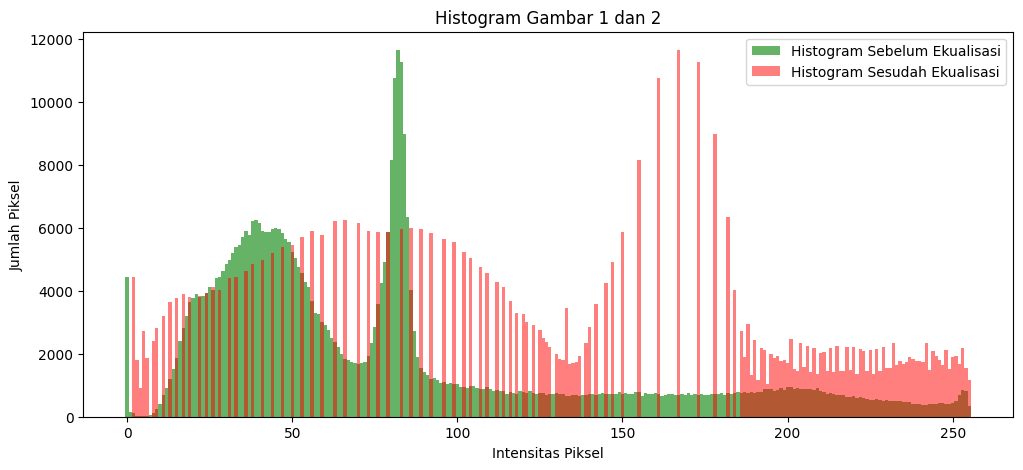

In [86]:
meledak_gray_hist = buat_hist(meledak_gray_norm)
meledak_ekual = histogram_equalization(meledak_gray_norm)
meledak_ekual_hist = buat_hist(meledak_ekual)

both_hist = plot_gabungan_histogram(meledak_gray_hist, meledak_ekual_hist, "Histogram Sebelum Ekualisasi", "Histogram Sesudah Ekualisasi", "Green", "Red", "Histogram Gambar 1 dan 2")

Kode di bawah ini digunakan untuk menampilkan gambar windut dan bunga yang sudah dalam bentuk grayscale.

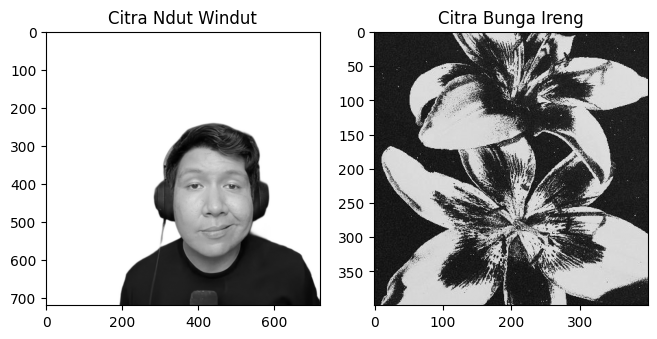

In [87]:
plt.figure(figsize=(12,8))

plt.subplot(1, 3, 1)
plt.title("Citra Ndut Windut")
plt.imshow(windut_gray, cmap='gray')
plt.subplot(1, 3, 2)
plt.title("Citra Bunga Ireng")
plt.imshow(bunga_gray, cmap='gray')

In [88]:
windut_norm = normalize_min_max(windut_gray)
bunga_norm = normalize_min_max(bunga_gray)

Kode di atas menerapkan fungsi normalisasi Min-Max pada dua citra grayscale, yaitu windut_gray dan bunga_gray. Proses ini dilakukan untuk memetakan kembali nilai intensitas piksel pada kedua gambar tersebut agar mengisi rentang penuh dari 0 hingga 255 secara optimal. Hasilnya disimpan dalam variabel windut_norm dan bunga_norm.

In [89]:
windut_ekual = histogram_equalization(windut_norm)
bunga_ekual = histogram_equalization(bunga_norm)

Kode di atas menerapkan fungsi ekualisasi histogram pada citra windut_norm dan bunga_norm untuk menyebarkan distribusi intensitas pikselnya secara lebih merata. Dengan melakukan proses ini, kontras pada kedua gambar tersebut ditingkatkan secara otomatis sehingga detail-detail yang tadinya mungkin samar menjadi lebih menonjol. Hasil akhirnya disimpan dalam variabel windut_ekual dan bunga_ekual.

In [90]:
def histogram_specification(source, target):
    height, width = source.shape

    # Hitung histogram source
    hist_source = np.zeros(256, dtype=int)
    for i in range(height):
        for j in range(width):
            hist_source[source[i, j]] += 1
    cdf_source = np.cumsum(hist_source)
    cdf_source = np.round(cdf_source * 255 / cdf_source[-1]).astype(np.uint8)

    # Hitung histogram target
    hist_target = np.zeros(256, dtype=int)
    for i in range(target.shape[0]):
        for j in range(target.shape[1]):
            hist_target[target[i, j]] += 1
    cdf_target = np.cumsum(hist_target)
    cdf_target = np.round(cdf_target * 255 / cdf_target[-1]).astype(np.uint8)

    # Buat mapping dari CDF source ke CDF target
    mapping = np.zeros(256, dtype=np.uint8)
    for source_val in range(256):
        diff = np.abs(cdf_source[source_val] - cdf_target)
        mapping[source_val] = np.argmin(diff)

    # Terapkan mapping ke gambar source
    result = np.zeros_like(source)
    for i in range(height):
        for j in range(width):
            result[i, j] = mapping[source[i, j]]

    return result

Fungsi histogram_specification atau yang dikenal sebagai histogram matching bertujuan untuk mengubah distribusi intensitas piksel pada citra sumber (source) agar mengikuti karakteristik distribusi atau nuansa dari citra target (target). Proses ini bekerja dengan cara menghitung dan menormalisasi Fungsi Distribusi Kumulatif (CDF) dari kedua citra tersebut, lalu mencari pasangan nilai intensitas yang memiliki selisih CDF terkecil untuk membuat sebuah tabel pemetaan (mapping). Hasil akhirnya adalah citra baru yang secara visual memiliki kontras, kecerahan, dan distribusi warna yang serupa dengan citra target tanpa menghilangkan struktur konten dari citra aslinya.

Kode di bawah ini menggunakan fungsi histogram_specification dengan menggunakan windut_ekual sebagai citra sumber dan bunga_img sebagai referensi targetnya. Melalui kode ini, distribusi intensitas piksel pada gambar windut dipetakan ulang agar mengikuti karakteristik kontras dan nuansa cahaya yang dimiliki oleh gambar bunga. Hasil spesifikasi tersebut seperti gambar di bawah ini.

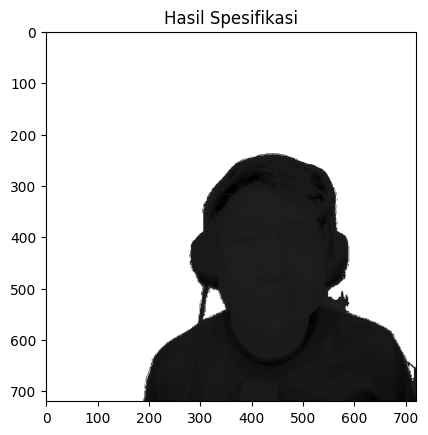

In [91]:
windut_spec = histogram_specification(windut_ekual, bunga_img)

plt.title("Hasil Spesifikasi")
plt.imshow(windut_spec, cmap='gray')

Kode ini berfungsi untuk menghitung dan memvisualisasikan distribusi intensitas piksel dari citra windut_spec yang merupakan hasil dari proses histogram matching sebelumnya. Pertama, fungsi buat_hist mendata frekuensi kemunculan setiap nilai kecerahan pada gambar tersebut, kemudian fungsi plot_histogram menampilkan data tersebut ke dalam grafik batang berwarna merah dengan judul "Spesifikasi Windut dengan Bunga". Hasil histogramnya terlihat seperti gambar di bawah ini. 

Histogram pada gambar tersebut menunjukkan distribusi intensitas piksel yang sangat tidak merata dengan dominasi yang besar pada intensitas sekitar 210. Puncak yang sangat tinggi pada nilai tersebut menandakan bahwa sebagian besar piksel dalam citra memiliki tingkat kecerahan yang hampir sama, yaitu berada pada area terang. Kondisi ini biasanya terjadi karena citra memiliki latar belakang atau area dominan dengan warna yang seragam dan cerah. Sementara itu, distribusi piksel pada intensitas rendah hingga menengah terlihat jauh lebih sedikit dan hanya membentuk beberapa puncak kecil di sekitar intensitas 0–30. Hal ini menunjukkan bahwa hanya sebagian kecil area citra yang memiliki warna gelap atau detail tertentu.

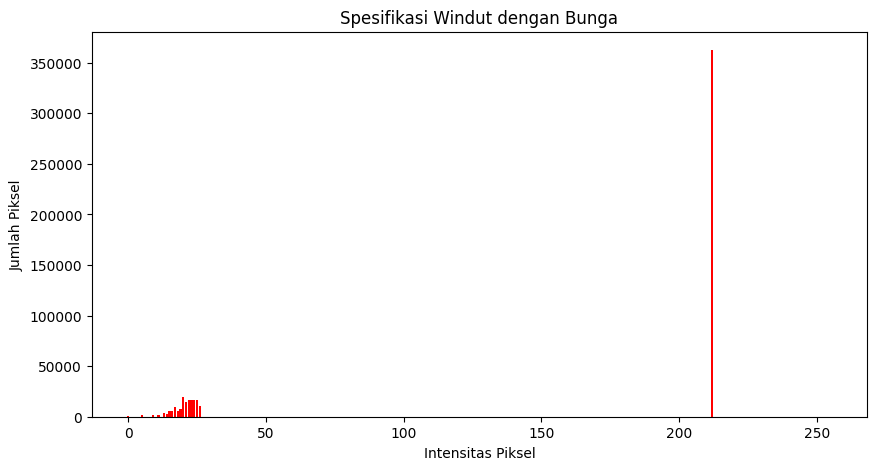

In [92]:
windut_hist = buat_hist(windut_spec)
windut_plot = plot_histogram(windut_hist, "Spesifikasi Windut dengan Bunga", "Red")

Kode di bawah ini hanya untuk menampilkan gambar dan ukuran piksel dari meledak_ekual dan windut_spec.

In [93]:
print(meledak_ekual.shape)
print(windut_spec.shape)

(680, 680)
(720, 720)


Kode di bawah ini berfungsi untuk melakukan pemotongan citra atau cropping pada variabel windut_spec dengan mengambil area spesifik dari koordinat kiri atas. Melalui teknik slicing array [0:680, 0:680], program hanya mengambil data piksel dari baris ke-0 hingga 680 dan kolom ke-0 hingga 680, sehingga menghasilkan gambar baru berukuran 680x680 piksel. Hasil cropping terlihat pada gambar di bawah ini.

(680, 680)
(680, 680)


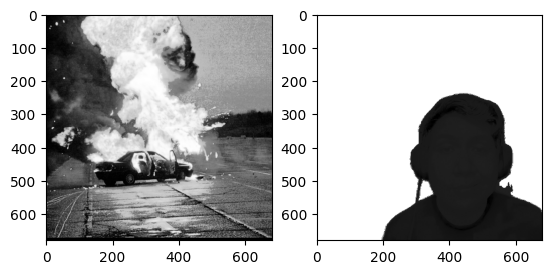

In [94]:
windut_crop = windut_spec[0:680, 0:680]

plt.subplot(1,2,1)
plt.imshow(meledak_ekual, cmap='gray')
plt.subplot(1,2,2)
plt.imshow(windut_crop, cmap='gray')

print(meledak_ekual.shape)
print(windut_crop.shape)

In [95]:
def stack_with_mask(background, foreground, mask):
    h, w = background.shape[:2]
    hasil = background.copy()
    
    for i in range(h):
        for j in range(w):
            if mask[i, j] == 255: 
                hasil[i, j] = foreground[i, j]
    return hasil

Fungsi stack_with_mask ini berfungsi untuk melakukan penggabungan dua citra secara selektif menggunakan teknik masking. Secara logis, fungsi ini bekerja seperti proses tempel-menempel, di mana variabel mask bertindak sebagai panduan. Jika sebuah piksel pada masker bernilai 255 (warna putih), maka piksel dari gambar latar depan (foreground) akan disalin ke atas gambar latar belakang (background). Sebaliknya, jika masker bernilai nol (hitam), posisi tersebut tetap menampilkan gambar latar belakang asli.

In [96]:
print(windut_gray.shape)
windut_crop2 = windut_gray[0:680, 0:680]
print(windut_crop2.shape)

(720, 720)
(680, 680)


Baris kode di atas hanya untuk melihat ukutan piksel dari gambar windut karena mau menyesuaikan ukuran pikselnya supaya sama.

Dengan menggunakan fungsi stack_with_mask, variabel windut_crop diposisikan sebagai latar belakang (background), sementara meledak_ekual berperan sebagai gambar latar depan (foreground) yang akan ditempelkan. Variabel windut_crop2 yang bertindak sebagai masker atau cetakan, hanya area pada masker yang bernilai putih yang akan melubangi latar belakang dan mengizinkan detail dari gambar ledakan muncul di posisi tersebut. Hasilnya diperlihatkan seperti gambar di bawah ini

(680, 680)


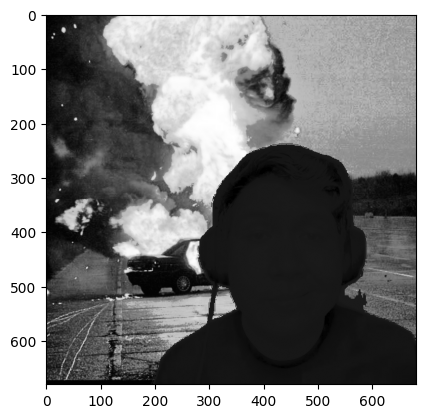

In [97]:
windut_meledak = stack_with_mask(windut_crop, meledak_ekual, windut_crop2)
plt.imshow(windut_meledak, cmap='gray')

print(windut_meledak.shape)

Kode di bawah ini digunakan untuk menghasilkan citra akhir dengan menggabungkan dua gambar dalam bentuk grayscale. Pertama, variabel windutdut dibuat dengan melakukan cropping pada citra windut_gray menggunakan slicing array untuk mengambil area dari baris 0 hingga 680 dan kolom 0 hingga 680. Proses ini dilakukan agar ukuran citra sesuai dengan gambar hasil penggabungan sebelumnya. Selanjutnya, variabel windut_akhir diperoleh dengan menjumlahkan citra windut_meledak dan windutdut menggunakan operasi penjumlahan array. Operasi ini bertujuan untuk mengombinasikan informasi intensitas piksel dari kedua gambar sehingga menghasilkan citra baru yang memuat detail dari kedua sumber citra tersebut. Hasil operasi citra ditampilkan melalui plt.imshow() dan ditunjukkan pada gambar di bawah ini.

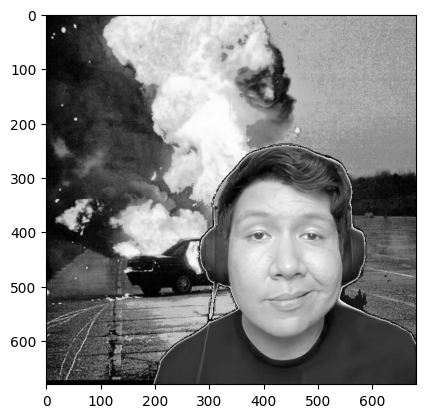

In [98]:
windutdut = windut_gray[0:680, 0:680]
windut_akhir = windut_meledak + windutdut

plt.imshow(windut_akhir, cmap='gray')

Baris kode di bawah ini menerapkan menggunakan fungsi histogram_specification pada citra hasil penggabungan, yaitu windut_meledak, dengan menggunakan citra langit_gray sebagai referensi atau targetnya. Tujuan utama dari proses ini adalah untuk menyesuaikan ulang distribusi intensitas warna, kontras, dan tingkat kecerahan dari gambar komposit tersebut agar selaras dengan nuansa pencahayaan dari gambar langit. Hasil akhirnya disimpan dalam variabel windut_spec_akhir. Hasil spesifikasi tersebut terlihat pada gambar di bawah ini.

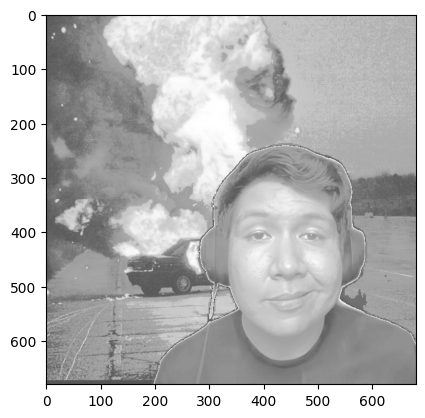

In [99]:
windut_spec_akhir = histogram_specification(windut_akhir, langit_gray)
plt.imshow(windut_spec_akhir, cmap='gray')

Melalui fungsi buat_hist, program menghitung sebaran frekuensi nilai piksel pada variabel windut_spec_akhir, yang kemudian ditampilkan dalam bentuk grafik batang berwarna merah menggunakan fungsi plot_histogram. Hasil histogram dapat dilihat pada gambar di bawah ini.

Histogram pada gambar “Spesifikasi Windut dengan Langit” menunjukkan bahwa distribusi intensitas piksel didominasi oleh nilai menengah hingga tinggi, terutama pada rentang sekitar 120–200. Puncak tertinggi terlihat berada di sekitar intensitas 140–150, yang menandakan bahwa sebagian besar area citra memiliki tingkat kecerahan sedang menuju terang. Hal ini sesuai dengan karakteristik citra yang kemungkinan mengandung area langit cukup luas, karena langit umumnya menghasilkan intensitas piksel yang lebih tinggi dibanding objek gelap. Selain itu, distribusi histogram tampak cukup menyebar dibanding histogram sebelumnya, sehingga variasi tingkat kecerahan pada citra lebih beragam.

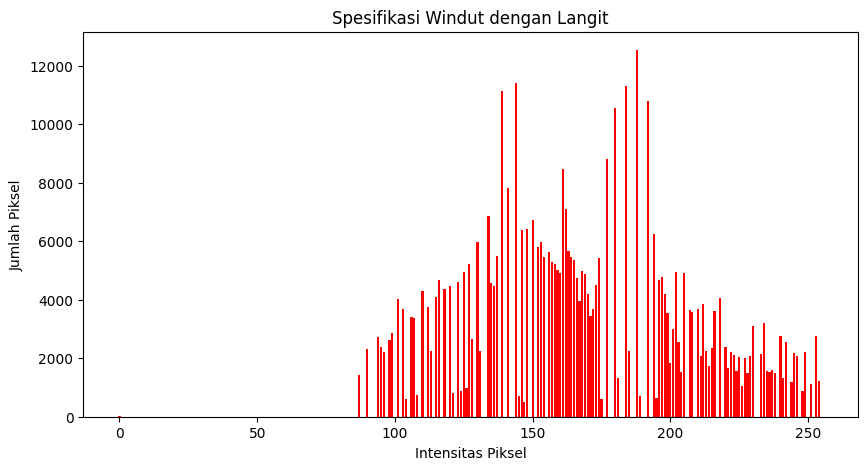

In [100]:
windut_akhir_hist = buat_hist(windut_spec_akhir)
windut_akhir_plot = plot_histogram(windut_akhir_hist, "Spesifikasi Windut dengan Langit", "Red")

Kode di bawah ini digunakan untuk membaca dan menampilkan dua buah citra menggunakan library OpenCV dan Matplotlib. Pertama, fungsi cv2.imread digunakan untuk membaca file gambar Meledak.png dan Windut.png dari folder Assets, kemudian masing-masing disimpan ke dalam variabel meledak_new dan windut_new. Setelah gambar berhasil dimuat, fungsi plt.subplot digunakan untuk membagi area tampilan menjadi satu baris dengan dua kolom agar kedua citra dapat ditampilkan secara berdampingan. Subplot pertama menampilkan gambar meledak_new, sedangkan subplot kedua menampilkan gambar windut_new menggunakan fungsi plt.imshow.

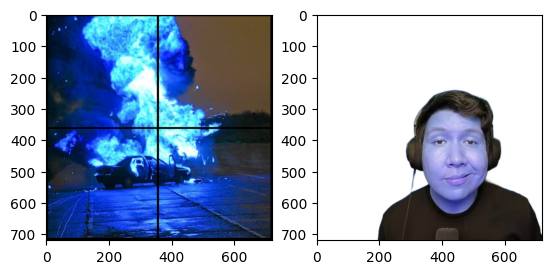

In [101]:
meledak_new = cv2.imread("Assets/Meledak.png")
windut_new = cv2.imread("Assets/Windut.png")

plt.subplot(1,2,1)
plt.imshow(meledak_new)
plt.subplot(1,2,2)
plt.imshow(windut_new)

Kode di bawah ini digunakan untuk memotong gambar meledak_new menjadi empat bagian berbeda menggunakan fungsi slice secara horizontal dan vertikal. Pada tahap pertama, gambar dipotong secara horizontal dengan parameter 'H', di mana meledak1 mengambil area baris 20 hingga 360 sebagai bagian atas gambar, sedangkan meledak2 mengambil area baris 380 hingga 720 sebagai bagian bawah gambar. Setelah itu, masing-masing potongan horizontal kembali dipotong secara vertikal menggunakan parameter 'V'. Variabel meledak3 dan meledak4 merupakan hasil pembagian sisi kiri dan kanan dari bagian atas gambar (meledak1), sedangkan meledak5 dan meledak6 merupakan hasil pembagian sisi kiri dan kanan dari bagian bawah gambar (meledak2). Dengan proses ini, gambar utama berhasil dipecah menjadi empat bagian terpisah yang nantinya dapat digunakan untuk proses manipulasi atau rekonstruksi citra. Hasil slicing seperti gambar di bawah ini.

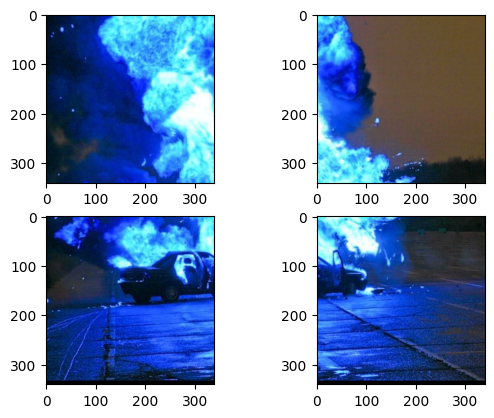

In [102]:
meledak1 = slice(meledak_new, 20, 360, 'H')
meledak2 = slice(meledak_new, 380, 720, 'H')
meledak3 = slice(meledak1, 10, 350, 'V')
meledak4 = slice(meledak1, 360, 700, 'V')
meledak5 = slice(meledak2, 10, 350, 'V')
meledak6 = slice(meledak2, 360, 700, 'V')

plt.subplot(2,2,1)
plt.imshow(meledak3)
plt.subplot(2,2,2)
plt.imshow(meledak4)
plt.subplot(2,2,3)
plt.imshow(meledak5)
plt.subplot(2,2,4)
plt.imshow(meledak6)

Kode di bawah ini digunakan untuk menggabungkan kembali potongan-potongan gambar yang sebelumnya telah dipisahkan menjadi beberapa bagian. Pertama, fungsi merge_image digunakan untuk menyatukan meledak3 dan meledak4 secara horizontal dengan parameter 'H', sehingga membentuk kembali bagian atas gambar yang disimpan pada variabel meledak34. Proses yang sama juga dilakukan pada meledak5 dan meledak6 untuk membentuk bagian bawah gambar yang disimpan dalam variabel meledak56. Setelah dua bagian utama tersebut terbentuk, fungsi merge_image kembali digunakan dengan parameter 'V' untuk menggabungkan meledak34 dan meledak56 secara vertikal sehingga menghasilkan satu citra utuh yang disimpan pada variabel meledak_full. Hasil citra seperti gambar di bawah ini.

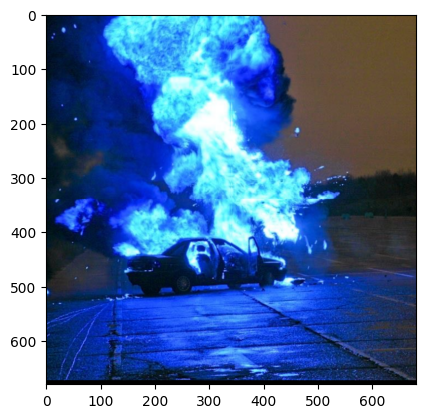

In [103]:
meledak34 = merge_image(meledak3, meledak4, 'H')
meledak56 = merge_image(meledak5, meledak6, 'H')

meledak_full = merge_image(meledak34, meledak56, 'V')

plt.imshow(meledak_full)

Kode di bawah ini digunakan untuk melakukan proses masking dan penggabungan dua citra berdasarkan kondisi nilai piksel pada gambar windut_new. Pertama, dibuat sebuah array kosong bernama hasil dengan ukuran dan jumlah channel yang sama seperti windut_new menggunakan fungsi np.zeros_like. Selanjutnya, program melakukan perulangan terhadap setiap piksel pada gambar meledak_full menggunakan nested loop berdasarkan tinggi dan lebar citra. Pada setiap piksel, program memeriksa nilai channel pertama (biru) dari gambar windut_new. Jika nilai piksel tersebut lebih besar dari 250, yang menandakan area sangat terang atau mendekati putih, maka piksel pada posisi tersebut akan diganti menggunakan piksel dari gambar meledak_full. Sebaliknya, jika nilainya tidak melebihi 235, maka piksel asli dari windut_new tetap dipertahankan. Dengan logika ini, area putih pada gambar Windut akan diisi menggunakan gambar ledakan, sedangkan area objek utama tetap mempertahankan citra aslinya. Selanjutnya, digunakan plt.imshow() untuk menampilkan citra hasil masking seperti pada gambar di bawah ini.

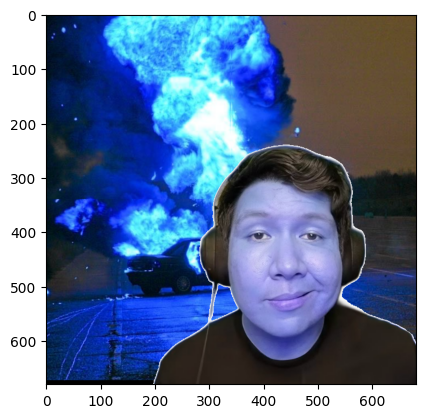

In [104]:
hasil = np.zeros_like(windut_new, dtype=int)

for i in range(meledak_full.shape[0]):
    for j in range(meledak_full.shape[1]):
        
        # Cek kondisi pada gambar_baru, tapi loop aman karena mengikuti ukuran bg_gabung
        if windut_new[i, j, 0] > 250:
            hasil[i, j] = meledak_full[i, j]
        else:
            hasil[i,j] = windut_new[i, j]
            

# 3. Tampilkan hasil
hasil = hasil[0:680, 0: 680]
plt.imshow(hasil, cmap="gray")
plt.show()

Program ini diawali dengan proses impor beberapa library utama, yaitu NumPy untuk pengolahan array dan operasi numerik, Matplotlib untuk visualisasi gambar dan histogram, serta OpenCV untuk membaca dan memproses citra digital. Beberapa gambar kemudian dibaca menggunakan kombinasi plt.imread dan cv2.imread, di mana Matplotlib mempertahankan format warna RGB sedangkan OpenCV menggunakan format BGR. Pada tahap awal pengolahan citra, gambar utama dipotong menggunakan teknik slicing baik secara horizontal maupun vertikal sehingga terbentuk beberapa bagian terpisah. Potongan-potongan tersebut kemudian digabungkan kembali menggunakan fungsi merge_image, baik secara vertikal maupun horizontal, hingga membentuk kembali citra utuh. Setelah proses rekonstruksi selesai, seluruh gambar dikonversi ke format grayscale menggunakan cv2.cvtColor agar setiap citra hanya memiliki satu kanal intensitas sehingga lebih mudah diproses pada tahapan peningkatan kualitas citra.

Tahap berikutnya adalah normalisasi intensitas menggunakan metode Min-Max normalization yang bertujuan menyebarkan nilai piksel ke rentang penuh 0–255 agar kontras gambar meningkat dan detail citra menjadi lebih jelas. Setelah itu diterapkan proses histogram equalization untuk meratakan distribusi intensitas piksel sehingga area gelap maupun terang pada gambar menjadi lebih seimbang. Analisis histogram menunjukkan bahwa sebelum ekualisasi, distribusi piksel masih terkonsentrasi pada rentang intensitas tertentu, terutama intensitas rendah hingga menengah, sehingga kontras citra kurang optimal dan beberapa detail sulit terlihat. Setelah ekualisasi dilakukan, distribusi histogram menjadi jauh lebih menyebar di seluruh rentang intensitas 0–255 yang menandakan peningkatan kontras serta variasi tingkat kecerahan yang lebih baik. Area terang dan gelap pada citra menjadi lebih mudah dibedakan sehingga kualitas visual gambar meningkat secara signifikan.

Selanjutnya dilakukan proses histogram specification atau histogram matching untuk menyesuaikan distribusi intensitas suatu citra agar mengikuti karakteristik citra referensi tertentu. Pada proses ini, gambar windut_ekual digunakan sebagai citra sumber dan gambar bunga sebagai target referensi. Hasil histogram menunjukkan adanya dominasi intensitas tinggi di sekitar nilai 210 yang menandakan sebagian besar piksel berada pada area terang dengan distribusi yang kurang merata. Kondisi tersebut mengindikasikan bahwa citra hasil spesifikasi memiliki latar belakang atau area dominan yang cerah dengan sedikit area gelap. Setelah itu dilakukan cropping pada citra agar ukurannya sesuai dengan gambar lain yang akan digabungkan. Teknik masking kemudian diterapkan menggunakan fungsi stack_with_mask untuk menggabungkan gambar ledakan dengan gambar hasil spesifikasi secara selektif berdasarkan masker tertentu. Pada proses ini, bagian putih pada masker memungkinkan area gambar ledakan muncul di atas latar belakang sehingga menghasilkan citra komposit baru.

Tahap selanjutnya adalah menerapkan kembali histogram specification pada citra gabungan menggunakan gambar langit sebagai referensi. Tujuan proses ini adalah menyesuaikan distribusi intensitas, kontras, dan nuansa pencahayaan gambar komposit agar menyerupai karakteristik langit. Hasil histogram akhir menunjukkan distribusi piksel yang lebih menyebar pada rentang intensitas menengah hingga tinggi, khususnya di sekitar 120–200, dengan puncak dominan pada intensitas 140–150. Hal ini menunjukkan bahwa sebagian besar area citra memiliki tingkat kecerahan sedang hingga terang yang sesuai dengan karakteristik visual langit. Dibandingkan histogram sebelumnya, distribusi intensitas pada tahap akhir terlihat lebih beragam dan seimbang sehingga citra memiliki pencahayaan yang lebih natural, detail objek lebih jelas, dan kualitas visual keseluruhan menjadi lebih baik.

Pada tahap akhir, program melakukan proses compositing atau penggabungan dua gambar dengan teknik masking berbasis intensitas piksel. Proses diawali dengan membaca dua citra utama, yaitu gambar ledakan (Meledak.png) dan gambar Windut (Windut.png) menggunakan OpenCV, kemudian keduanya ditampilkan berdampingan menggunakan Matplotlib untuk memastikan gambar berhasil dimuat dengan benar. Selanjutnya, gambar ledakan dipotong menjadi beberapa bagian menggunakan fungsi slice baik secara horizontal maupun vertikal sehingga diperoleh empat potongan citra terpisah. Potongan-potongan tersebut kemudian digabungkan kembali menggunakan fungsi merge_image hingga membentuk satu gambar utuh yang disimpan pada variabel meledak_full. Setelah proses rekonstruksi selesai, dilakukan masking dengan membuat array kosong bernama hasil yang memiliki ukuran sama dengan citra Windut. Program kemudian menelusuri setiap piksel pada gambar menggunakan nested loop dan memeriksa nilai intensitas pada channel pertama gambar windut_new. Jika nilai piksel lebih besar dari 250, yang menandakan area terang atau mendekati putih, maka piksel tersebut diganti menggunakan piksel dari gambar ledakan (meledak_full). Sebaliknya, jika nilai piksel tidak memenuhi kondisi tersebut, maka piksel asli dari gambar Windut tetap dipertahankan. Dengan teknik ini, area latar belakang terang pada gambar Windut berhasil digantikan oleh gambar ledakan, sementara objek utama tetap mempertahankan detail dan warna aslinya. Hasil akhir menunjukkan proses masking dan compositing berhasil menghasilkan citra gabungan yang tampak lebih realistis dan menyatu secara visual.
